In [1]:
#data format library
import h5py

#numpy
import numpy as np
import pandas as pd
import numpy.ma as ma
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams['pdf.fonttype'] = 42
# %matplotlib notebook
import sys
sys.path.append('./utils/')
import matplotlib.colors as pltcolors
import os
import copy
import partitioning_methods as cl
import coarse_graining as cgm
import operator_calculations as op_calc
import delay_embedding as embed
import diffusion_maps as dmaps
import stats
import time

np.random.seed(42)

import importlib
importlib.reload(op_calc)

<module 'operator_calculations' from '/flash/StephensU/Gautam/HMD/./utils/operator_calculations.py'>

In [11]:
Fig_path = '/flash/StephensU/Gautam/Figures/Comparing_MultiScale_Dynamics/Fig_zebrafish/'

In [2]:
path_to_filtered_data = '/flash/StephensU/Gautam/HMD/Results/Zebrafish/'
D_int = np.load(path_to_filtered_data + 'D_int.npy')

In [3]:
from scipy.sparse.linalg import eigs
sorted_d = np.sort(D_int, axis=1)
k=50
M = dmaps.self_tuning_diffusion_tmat(D_int,sorted_d,k,1)

In [6]:
from scipy.sparse.linalg import eigsh
# P = L / L.sum(axis=1)[:, np.newaxis]
diff_eig, diff_ev = eigsh(M,k=10,which='LA')
diff_inv_mes = op_calc.stationary_distribution(M)
diff_eigvecs = diff_ev / np.sqrt((diff_ev**2 * diff_inv_mes[:, None]).sum(axis=0))

sorted_indices = np.argsort(diff_eig.real)[::-1]
diff_eig = diff_eig[sorted_indices].real
diff_eig[diff_eig<1e-12] = 0
diff_dists = diff_eig*(diff_eigvecs[:,sorted_indices].real)

In [7]:
def weighted_fuzzy_cmeans(X,n_clusters,weights,m: float = 2.0,max_iter: int = 5000,tol: float = 1e-10,random_state=42):
    rng = np.random.default_rng(random_state)
    n_samples, n_features = X.shape

    if weights is None:
        weights = np.ones(n_samples)
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    U = rng.dirichlet(np.ones(n_clusters), size=n_samples)
    eps = np.finfo(np.float64).eps
    exp = 2.0 / (m - 1)  # applied to distances, not squared distances

    for _ in range(max_iter):
        U_prev = U.copy()

        # Weighted centroid update
        um = U ** m
        wum = um * weights[:, np.newaxis]
        centers = (wum.T @ X) / wum.sum(axis=0)[:, np.newaxis]

        # Membership update — use Euclidean distances (not squared)
        diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
        dist = np.sqrt(np.maximum((diff ** 2).sum(axis=-1), eps))  # ← fix
        ratio = dist[:, :, np.newaxis] / dist[:, np.newaxis, :]
        U = 1.0 / (ratio ** exp).sum(axis=2)

        if np.linalg.norm(U - U_prev) < tol:
            break

    return U.T, centers, U.argmax(axis=1)

num_eigfs=2
X = diff_dists[:,1:num_eigfs+1]

cgs=3

m=2
cr, centers, labels = weighted_fuzzy_cmeans(
    X,
    n_clusters=cgs,
    weights=inv_measure,
    m=m,
    random_state=42,
)

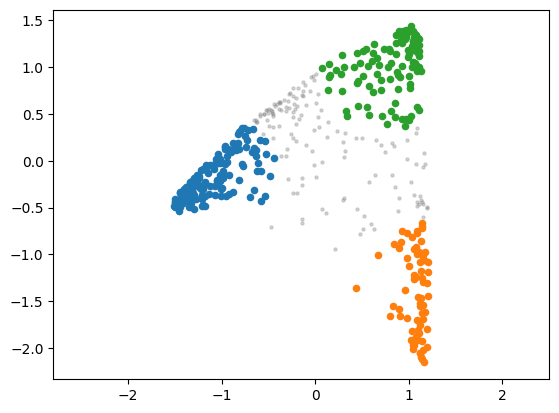

In [15]:
cluster_idx1 = np.where(cr[0] > 0.8)[0]
cluster_idx2 = np.where(cr[1] > 0.8)[0]
cluster_idx3 = np.where(cr[2] > 0.8)[0]

cluster_idxs = [cluster_idx1,cluster_idx2,cluster_idx3]

plt.scatter(diff_dists[:,1],-1*diff_dists[:,2],s=5,c='grey',alpha=0.3)
for i in range(3):
    plt.scatter(diff_dists[cluster_idxs[i],1],-1*diff_dists[cluster_idxs[i],2],s=20)
plt.axis('equal')
plt.savefig(Fig_path+'/Diff_map_extremes.pdf')

In [89]:
#Fig S5 B2
path_to_filtered_data = '/flash/StephensU/Gautam/HMD/Results/Zebrafish/'
len_sim=5000
# nbout_range = [5,10,20,50,100,500,1000,3162]
nbout_range = [3]
ac_samples_nbouts=[]
dr=.02
for kn,n_bouts in enumerate(nbout_range):
    ac_samples_group = []
    for clus in range(1,4):
        print(clus,n_bouts,dr)
        f = h5py.File(path_to_filtered_data + '/est_probs/hunt_probs_group_{}_nbouts_{}_l_{:.2f}.h5'.format(clus,n_bouts,dr),'r')
        ac_samples = np.array(f['ac_samples'])
        f.close()
        ac_samples_group.append(ac_samples)
    ac_samples_group = np.asarray(ac_samples_group)
    ac_samples_nbouts.append(ac_samples_group)
    print(n_bouts)


1 3 0.02
2 3 0.02
3 3 0.02
3


[0.27778274 0.32775137 0.39446583]


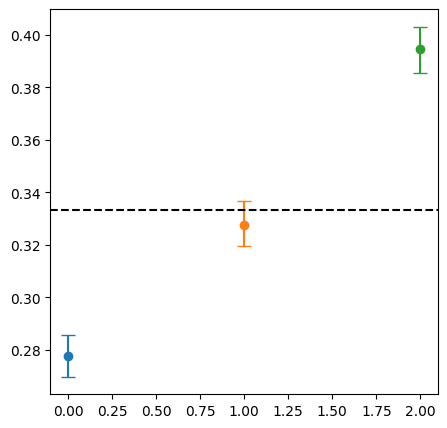

In [94]:
hunt_rate_N = np.zeros((len(nbout_range),3,3))

n_sims = ac_samples_nbouts[0].shape[1]
for kn,n_bouts in enumerate(nbout_range):
    ac_samples_group = ac_samples_nbouts[kn]
    n_times=1000
    mean = ac_samples_group.mean(axis=1)
    mean_norm = mean/mean.sum()
    samples = []
    for k in range(n_times):
        mean_s = ac_samples_group[:,np.random.randint(0,n_sims,n_sims)].mean(axis=1)
        samples.append(mean_s/mean_s.sum())
    cil = np.percentile(samples,2.5,axis=0)
    ciu = np.percentile(samples,97.5,axis=0)
    plt.figure(figsize=(5,5))
    # plt.title('nbouts = {}'.format(n_bouts))
    print(mean_norm)
    for kg in np.arange(3):
        plt.errorbar(kg,mean_norm[kg],yerr = [[mean_norm[kg]-cil[kg]],[ciu[kg]-mean_norm[kg]]],color='C{}'.format(kg),marker='o',capsize=5)
#     plt.savefig('hunt_prob_dr_0.02_nbouts_{}.pdf'.format(n_bouts))
    plt.axhline(1/3.,c='k',ls='--')
    plt.savefig(Fig_path + 'clus_hunt_probs.pdf')
    plt.show()
    hunt_rate_N[kn] = np.vstack([mean_norm,cil,ciu]).T

In [105]:
rmin=0.8
maxR = 100.
dist_range = np.logspace(np.log10(rmin),np.log10(maxR),50)

In [106]:
print(path_to_filtered_data)

/flash/StephensU/Gautam/HMD/Results/Zebrafish/


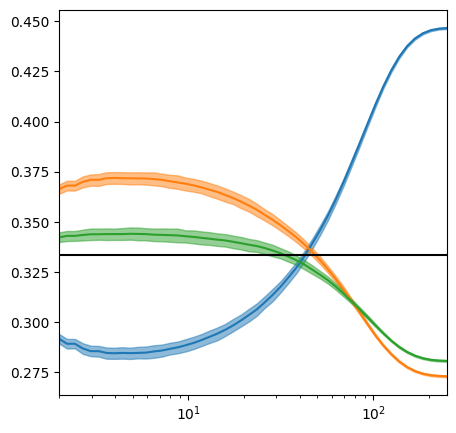

In [110]:
len_sim=1000
l_range = [.2,.4,.6]
for dr in [l_range[1]]:
    f = h5py.File(path_to_filtered_data + '/est_probs/bootstrap_detect_probs_groups_nbouts_{}_l_{:.2f}.h5'.format(len_sim,dr),'r')
    mean_ci = np.array(f['mean_ci'])
    dist_range = np.array(f['dist_range'])
    f.close()
    plt.figure(figsize=(5,5))
    # plt.title('dr = {:.2f},len_sim={}'.format(dr,len_sim))
    for clu in np.arange(3):
        mean = mean_ci[:,clu,0]
        cil = mean_ci[:,clu,1]
        ciu = mean_ci[:,clu,2]
        plt.plot(dist_range/0.4,mean, c='C{}'.format(clu))
        plt.fill_between(dist_range/0.4,cil,ciu,alpha=.5, color='C{}'.format(clu))

    # plt.ylim(0.1,.45)
    plt.axhline(1/3,c='k',ls='--')
    plt.xscale('log')
    plt.xlim(2,250)
#     plt.savefig('detect_probs_dr_{:.2f}.pdf'.format(dr))
    # plt.yscale('log')
    plt.savefig(Fig_path + 'clus_detect_probs.pdf')
    plt.show()